# Exploratory Data Analysis

## Objective

The purpose of this phase is to explore the cleaned dataset, identify patterns, discover relationships between variables, detect potential outliers, and extract business insights before training machine learning models.

The findings obtained during this analysis will guide the feature engineering process and help understand the factors associated with customer churn.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional configuration for visual improvement

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [2]:
# Load cleaned dataset

df = pd.read_csv("../data/processed/customer_churn_clean.csv")

display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Overview

Before starting the exploratory analysis, the cleaned dataset is inspected to confirm its dimensions and structure.

In [3]:
# Display dataset shape

display(df.shape)

# Display dataset information

display(df.info())

(7032, 21)

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

None

## Customer Churn Distribution

Understanding the distribution of the target variable is essential before analyzing relationships with other features.

This analysis provides an overview of customer retention and churn rates.

In [4]:
# Display churn counts

display(df["Churn"].value_counts())

# Display churn percentages

display(df["Churn"].value_counts(normalize=True).mul(100).round(2))

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

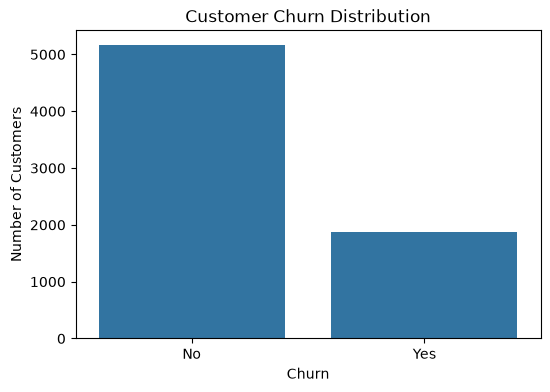

In [5]:
# Plot churn distribution

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## Numerical Feature Distribution

The numerical variables are analyzed to understand their distributions and identify potential skewness or unusual patterns.

In [6]:
# Define numerical features

numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

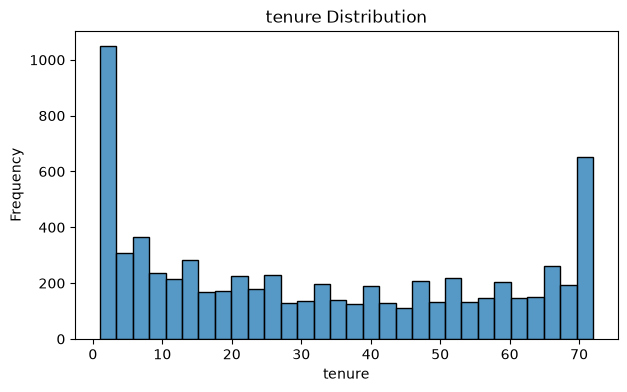

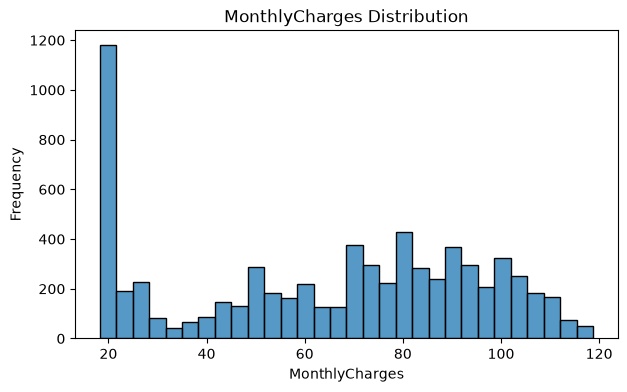

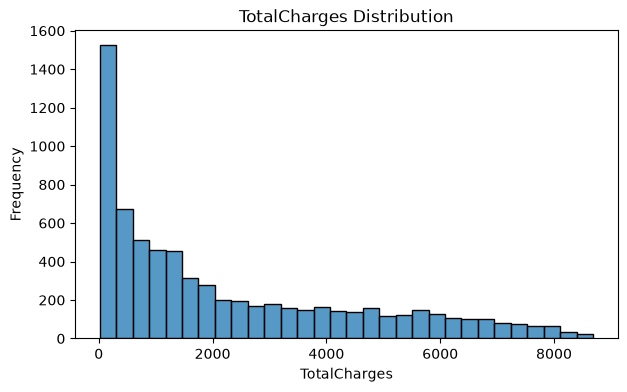

In [7]:
# Plot histograms

for column in numerical_features:

    plt.figure(figsize=(7,4))

    sns.histplot(df[column], bins=30)

    plt.title(f"{column} Distribution")

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.show()

## Outlier Detection

Boxplots are used to identify potential outliers in numerical variables.

Detecting outliers helps understand the distribution of the data and determine whether further treatment is necessary.

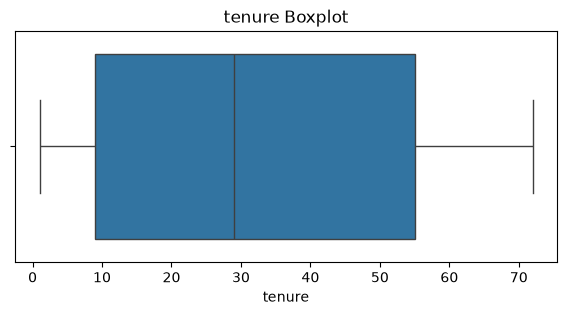

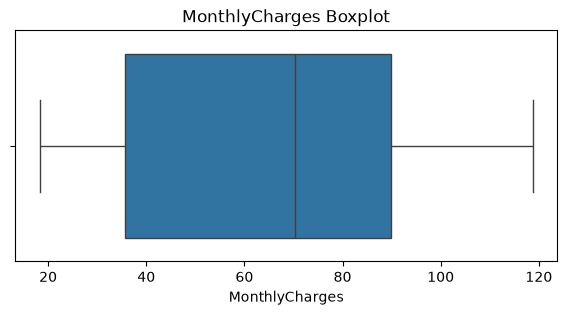

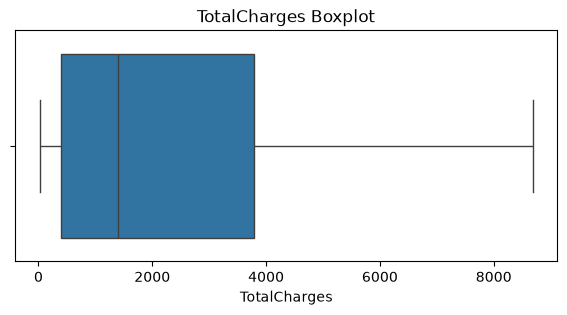

In [8]:
# Plot boxplots

for column in numerical_features:

    plt.figure(figsize=(7,3))

    sns.boxplot(x=df[column])

    plt.title(f"{column} Boxplot")

    plt.show()

## Correlation Analysis

Correlation measures the strength of the linear relationship between numerical variables.

This analysis helps identify variables that may contain redundant information.

In [9]:
# Compute correlation matrix

correlation = df[numerical_features].corr()

display(correlation)

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


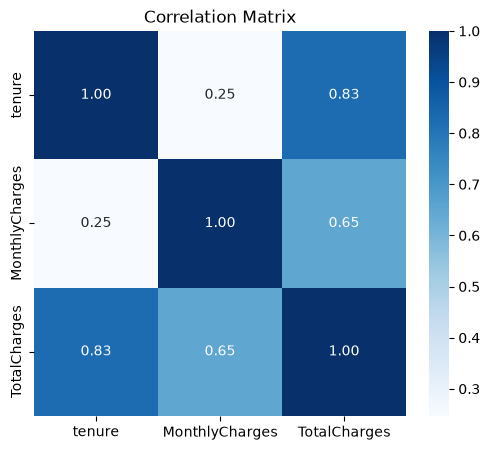

In [10]:
# Plot correlation heatmap

plt.figure(figsize=(6,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Customer Churn by Categorical Features

Categorical variables are analyzed to identify potential relationships with customer churn.

This analysis helps detect characteristics that may influence customer retention.

In [11]:
# Define categorical features

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

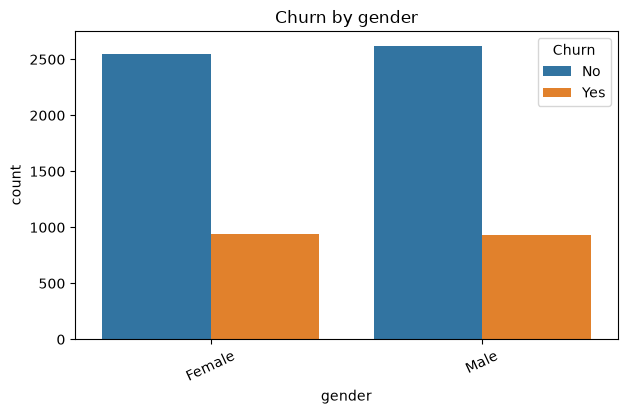

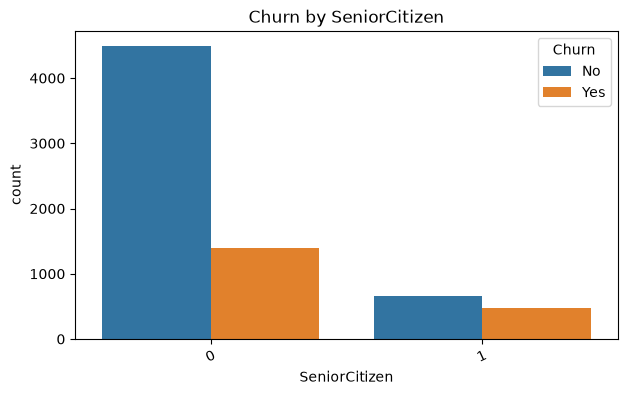

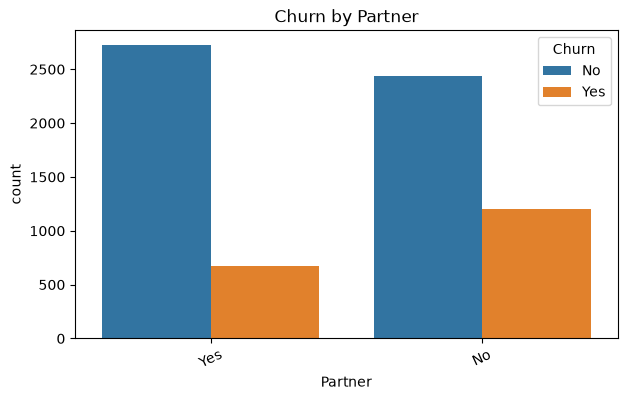

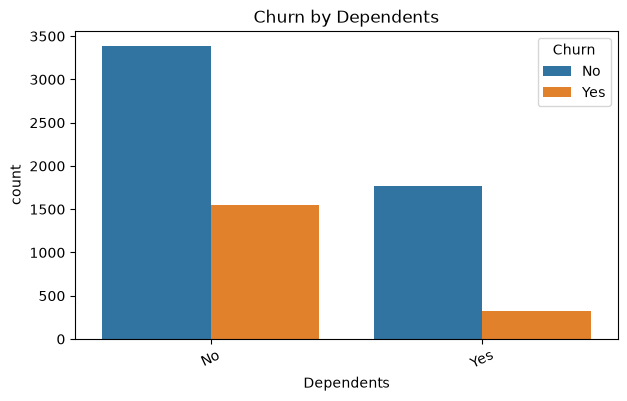

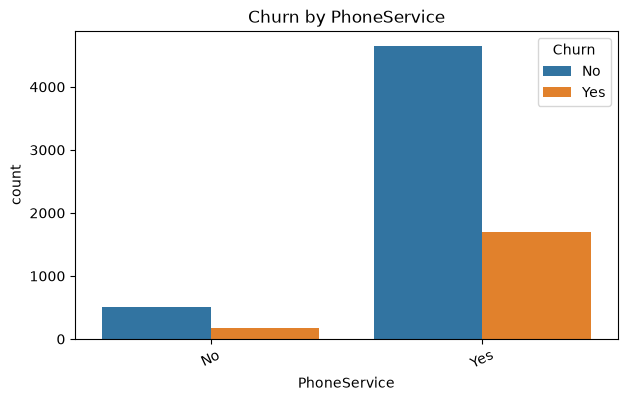

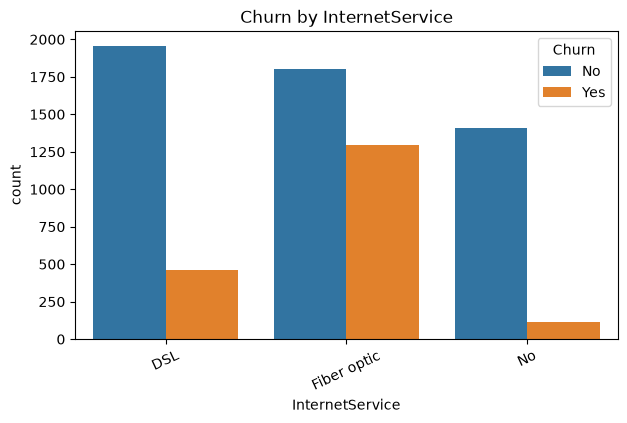

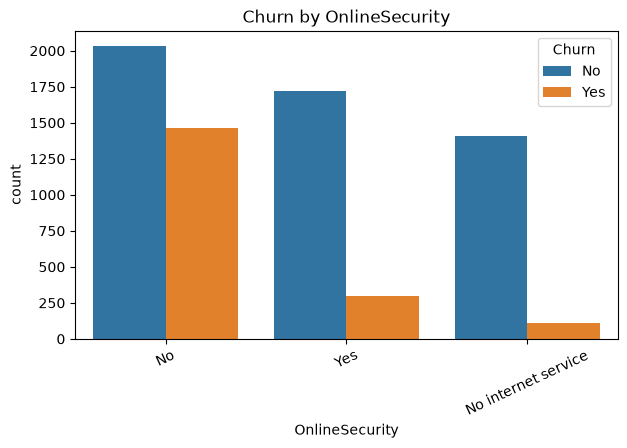

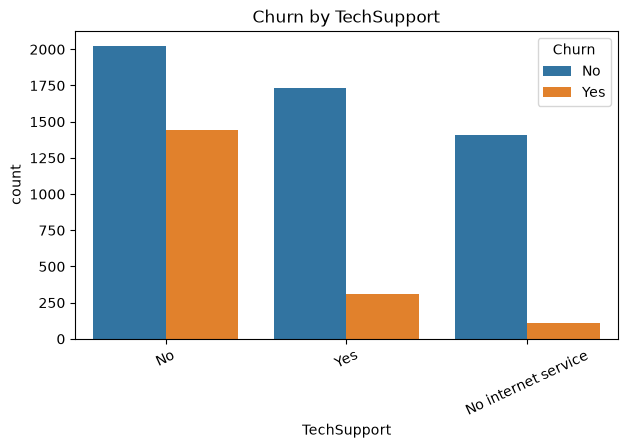

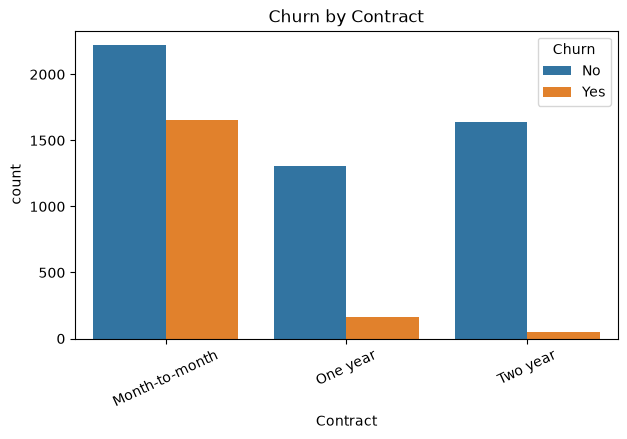

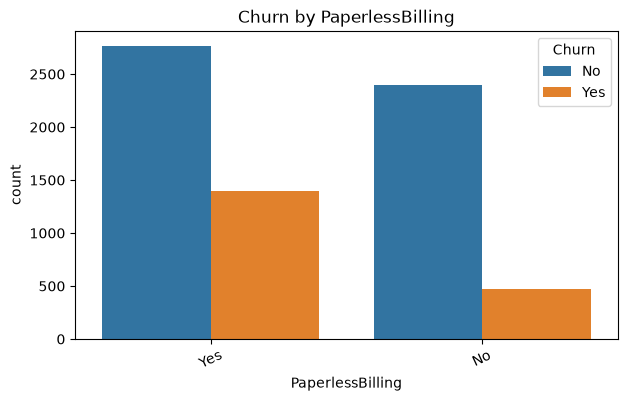

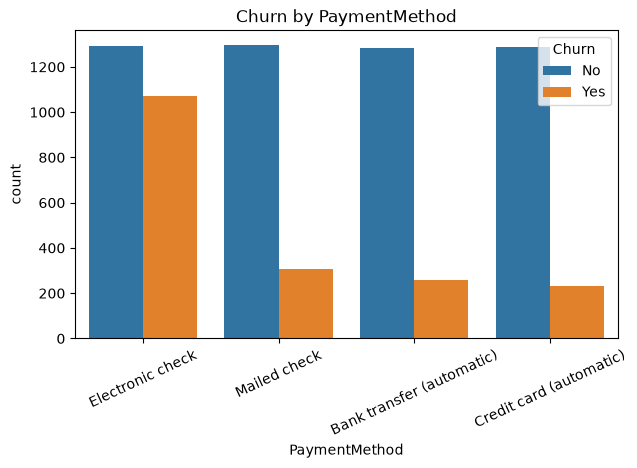

In [12]:
# Plot categorical features against churn

for column in categorical_features:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=column,
        hue="Churn"
    )

    plt.title(f"Churn by {column}")

    plt.xticks(rotation=25)

    plt.show()

## Customer Churn by Numerical Features

Numerical variables are compared across churn categories to identify differences between retained and churned customers.

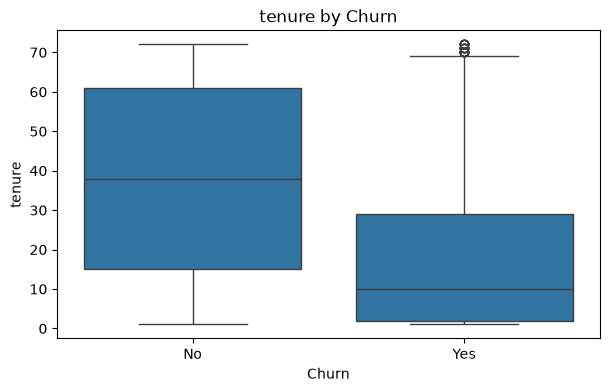

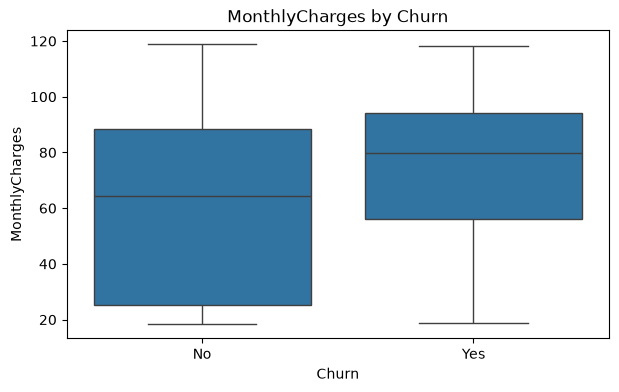

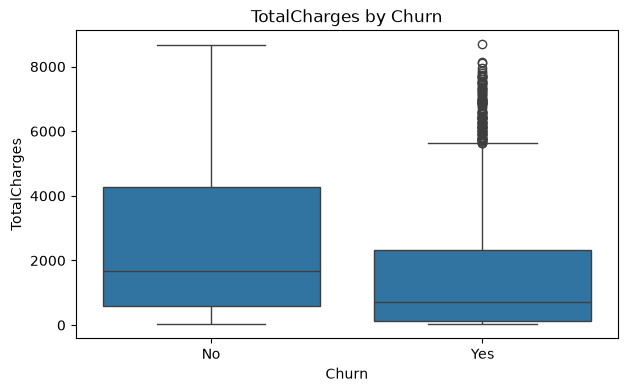

In [13]:
# Plot numerical variables by churn

for column in numerical_features:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        x="Churn",
        y=column
    )

    plt.title(f"{column} by Churn")

    plt.show()

## Churn Rate by Categorical Features

Absolute customer counts provide useful context, but they can be misleading when categories have different population sizes.

Churn rate is calculated within each category to provide a more meaningful comparison of customer retention behavior.

In [14]:
# Calculate churn rate by categorical feature

for column in categorical_features:

    churn_rate = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    print(f"\n{column}")
    display(churn_rate.round(2))


gender


gender
Female    26.96
Male      26.20
Name: Churn, dtype: float64


SeniorCitizen


SeniorCitizen
1    41.68
0    23.65
Name: Churn, dtype: float64


Partner


...

Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64


PaperlessBilling


PaperlessBilling
Yes    33.59
No     16.38
Name: Churn, dtype: float64


PaymentMethod


PaymentMethod
Electronic check             45.29
Mailed check                 19.20
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Name: Churn, dtype: float64

## EDA Key Findings

The exploratory analysis revealed several patterns associated with customer churn.

- Customers with month-to-month contracts show substantially higher churn than customers with longer-term contracts.
- Customers using electronic check as their payment method show relatively high churn.
- Fiber optic internet customers show higher churn compared with customers without internet service.
- Customers without Online Security or Tech Support tend to show higher churn.
- Customers with shorter tenure are more likely to churn.
- Customers with higher monthly charges show higher churn levels.
- Total charges are strongly related to tenure, which is expected because total charges accumulate over time.
- The numerical features contain different distributions and potential outliers that should be considered during modeling.